# Time-Series Single-Contract Factor Research

This notebook tests factors on **individual futures contracts** (time-series approach).
Unlike the cross-sectional `research_workflow_futures.ipynb`, each model here trains
on a **single contract's history** and predicts that contract's own future return.

**Workflow:**
1. Liquidity screening — rank all contracts by avg daily turnover, keep Top N
2. IC analysis — for each (contract, factor, horizon 1..10d): compute Spearman IC and ICIR
3. IC heatmaps — visualise which factors work on which contracts at which horizons
4. ML per contract — train LightGBM per contract, evaluate OOS Sharpe
5. Summary report — cross-contract comparison table

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr

from vnpy.alpha import AlphaLab
from vnpy.alpha.dataset import AlphaDataset, Segment
from vnpy.alpha.model.models.lgb_model import LgbModel
from vnpy.trader.constant import Interval

# ─────────────────────────────────────────────
#  USER CONFIGURATION
# ─────────────────────────────────────────────

LAB_PATH     = "./lab/futures"
INTERVAL     = Interval.DAILY

TOP_N        = 15          # keep top N contracts by avg daily turnover
HORIZONS     = list(range(1, 11))   # 1 .. 10 day forward returns for IC analysis
ML_HORIZON   = 5           # forward return horizon used for ML label
EXTENDED_DAYS = 120        # extra lookback days for feature warm-up

TRAIN_PERIOD = ("2019-01-01", "2021-12-31")
VALID_PERIOD = ("2022-01-01", "2022-12-31")
TEST_PERIOD  = ("2023-01-01", "2024-12-31")

# ── Build all 158 Alpha158 factors programmatically ──────────────────
_windows = [5, 10, 20, 30, 60]

FACTORS = {}

# Candlestick pattern (9)
FACTORS["kmid"]   = "(close - open) / open"
FACTORS["klen"]   = "(high - low) / open"
FACTORS["kmid_2"] = "(close - open) / (high - low + 1e-12)"
FACTORS["kup"]    = "(high - ts_greater(open, close)) / open"
FACTORS["kup_2"]  = "(high - ts_greater(open, close)) / (high - low + 1e-12)"
FACTORS["klow"]   = "(ts_less(open, close) - low) / open"
FACTORS["klow_2"] = "((ts_less(open, close) - low) / (high - low + 1e-12))"
FACTORS["ksft"]   = "(close * 2 - high - low) / open"
FACTORS["ksft_2"] = "(close * 2 - high - low) / (high - low + 1e-12)"

# Price ratios (4)
for field in ["open", "high", "low", "vwap"]:
    FACTORS[f"{field}_0"] = f"{field} / close"

# Time-series price/volume features (5 windows × 27 families = 135)
for w in _windows:
    FACTORS[f"roc_{w}"]   = f"ts_delay(close, {w}) / close"
for w in _windows:
    FACTORS[f"ma_{w}"]    = f"ts_mean(close, {w}) / close"
for w in _windows:
    FACTORS[f"std_{w}"]   = f"ts_std(close, {w}) / close"
for w in _windows:
    FACTORS[f"beta_{w}"]  = f"ts_slope(close, {w}) / close"
for w in _windows:
    FACTORS[f"rsqr_{w}"]  = f"ts_rsquare(close, {w})"
for w in _windows:
    FACTORS[f"resi_{w}"]  = f"ts_resi(close, {w}) / close"
for w in _windows:
    FACTORS[f"max_{w}"]   = f"ts_max(high, {w}) / close"
for w in _windows:
    FACTORS[f"min_{w}"]   = f"ts_min(low, {w}) / close"
for w in _windows:
    FACTORS[f"qtlu_{w}"]  = f"ts_quantile(close, {w}, 0.8) / close"
for w in _windows:
    FACTORS[f"qtld_{w}"]  = f"ts_quantile(close, {w}, 0.2) / close"
for w in _windows:
    FACTORS[f"rank_{w}"]  = f"ts_rank(close, {w})"
for w in _windows:
    FACTORS[f"rsv_{w}"]   = f"(close - ts_min(low, {w})) / (ts_max(high, {w}) - ts_min(low, {w}) + 1e-12)"
for w in _windows:
    FACTORS[f"imax_{w}"]  = f"ts_argmax(high, {w}) / {w}"
for w in _windows:
    FACTORS[f"imin_{w}"]  = f"ts_argmin(low, {w}) / {w}"
for w in _windows:
    FACTORS[f"imxd_{w}"]  = f"(ts_argmax(high, {w}) - ts_argmin(low, {w})) / {w}"
for w in _windows:
    FACTORS[f"corr_{w}"]  = f"ts_corr(close, ts_log(volume + 1), {w})"
for w in _windows:
    FACTORS[f"cord_{w}"]  = f"ts_corr(close / ts_delay(close, 1), ts_log(volume / ts_delay(volume, 1) + 1), {w})"
for w in _windows:
    FACTORS[f"cntp_{w}"]  = f"ts_mean(close > ts_delay(close, 1), {w})"
for w in _windows:
    FACTORS[f"cntn_{w}"]  = f"ts_mean(close < ts_delay(close, 1), {w})"
for w in _windows:
    FACTORS[f"cntd_{w}"]  = f"ts_mean(close > ts_delay(close, 1), {w}) - ts_mean(close < ts_delay(close, 1), {w})"
for w in _windows:
    FACTORS[f"sump_{w}"]  = f"ts_sum(ts_greater(close - ts_delay(close, 1), 0), {w}) / (ts_sum(ts_abs(close - ts_delay(close, 1)), {w}) + 1e-12)"
for w in _windows:
    FACTORS[f"sumn_{w}"]  = f"ts_sum(ts_greater(ts_delay(close, 1) - close, 0), {w}) / (ts_sum(ts_abs(close - ts_delay(close, 1)), {w}) + 1e-12)"
for w in _windows:
    FACTORS[f"sumd_{w}"]  = f"(ts_sum(ts_greater(close - ts_delay(close, 1), 0), {w}) - ts_sum(ts_greater(ts_delay(close, 1) - close, 0), {w})) / (ts_sum(ts_abs(close - ts_delay(close, 1)), {w}) + 1e-12)"
for w in _windows:
    FACTORS[f"vma_{w}"]   = f"ts_mean(volume, {w}) / (volume + 1e-12)"
for w in _windows:
    FACTORS[f"vstd_{w}"]  = f"ts_std(volume, {w}) / (volume + 1e-12)"
for w in _windows:
    FACTORS[f"wvma_{w}"]  = f"ts_std(ts_abs(close / ts_delay(close, 1) - 1) * volume, {w}) / (ts_mean(ts_abs(close / ts_delay(close, 1) - 1) * volume, {w}) + 1e-12)"
for w in _windows:
    FACTORS[f"vsump_{w}"] = f"ts_sum(ts_greater(volume - ts_delay(volume, 1), 0), {w}) / (ts_sum(ts_abs(volume - ts_delay(volume, 1)), {w}) + 1e-12)"
for w in _windows:
    FACTORS[f"vsumn_{w}"] = f"ts_sum(ts_greater(ts_delay(volume, 1) - volume, 0), {w}) / (ts_sum(ts_abs(volume - ts_delay(volume, 1)), {w}) + 1e-12)"
for w in _windows:
    FACTORS[f"vsumd_{w}"] = f"(ts_sum(ts_greater(volume - ts_delay(volume, 1), 0), {w}) - ts_sum(ts_greater(ts_delay(volume, 1) - volume, 0), {w})) / (ts_sum(ts_abs(volume - ts_delay(volume, 1)), {w}) + 1e-12)"

# All futures candidates (same list as research_workflow_futures.ipynb)
ALL_FUTURES = [
    "rb88.SHFE", "hc88.SHFE", "i88.DCE", "j88.DCE", "jm88.DCE",
    "cu88.SHFE", "al88.SHFE", "zn88.SHFE", "ni88.SHFE",
    "au88.SHFE", "ag88.SHFE",
    "ru88.SHFE", "sc88.INE", "TA88.CZCE", "pp88.DCE",
    "m88.DCE", "y88.DCE", "p88.DCE", "c88.DCE", "a88.DCE",
    "SR88.CZCE", "CF88.CZCE",
]

lab = AlphaLab(LAB_PATH)
print(f"Config: TOP_N={TOP_N}, HORIZONS=1..{max(HORIZONS)}, ML_HORIZON={ML_HORIZON}")
print(f"Total factors: {len(FACTORS)}")
print(f"Factor families: kmid/klen/kup/klow/ksft(9), price_ratios(4), " +
      f"roc/ma/std/beta/rsqr/resi/max/min/qtlu/qtld/rank/rsv/imax/imin/imxd/" +
      f"corr/cord/cntp/cntn/cntd/sump/sumn/sumd/vma/vstd/wvma/vsump/vsumn/vsumd × {_windows}")

Config: TOP_N=15, HORIZONS=1..10, ML_HORIZON=5
Total factors: 158
Factor families: kmid/klen/kup/klow/ksft(9), price_ratios(4), roc/ma/std/beta/rsqr/resi/max/min/qtlu/qtld/rank/rsv/imax/imin/imxd/corr/cord/cntp/cntn/cntd/sump/sumn/sumd/vma/vstd/wvma/vsump/vsumn/vsumd × [5, 10, 20, 30, 60]


## Cell 2 — Liquidity Screening
Rank all contracts by average daily turnover (CNY) over the test period.
Turnover is more comparable than volume (which is in lots and varies by contract size).

In [2]:
print("Loading turnover data for liquidity screening...")
df_liq = lab.load_bar_df(ALL_FUTURES, INTERVAL, TEST_PERIOD[0], TEST_PERIOD[1], extended_days=0)

# Note: load_bar_df normalises prices by dividing by first close, but volume/turnover are raw
liquidity = (
    df_liq
    .group_by("vt_symbol")
    .agg(
        pl.mean("turnover").alias("avg_daily_turnover"),
        pl.mean("volume").alias("avg_daily_volume"),
        pl.count("datetime").alias("trading_days")
    )
    .sort("avg_daily_turnover", descending=True)
)

# Display full ranking
liq_pd = liquidity.to_pandas()
liq_pd["rank"] = range(1, len(liq_pd) + 1)
liq_pd["avg_daily_turnover"] = (liq_pd["avg_daily_turnover"] / 1e8).round(2)  # in 亿元
liq_pd["avg_daily_volume"] = liq_pd["avg_daily_volume"].round(0).astype(int)
liq_pd = liq_pd[["rank", "vt_symbol", "avg_daily_turnover", "avg_daily_volume", "trading_days"]]
liq_pd.columns = ["Rank", "Contract", "Avg Daily Turnover (亿)", "Avg Daily Volume (lots)", "Trading Days"]
display(liq_pd)

SELECTED = liquidity.head(TOP_N)["vt_symbol"].to_list()
print(f"\nSelected top {TOP_N} by turnover:")
for i, s in enumerate(SELECTED, 1):
    print(f"  {i:2d}. {s}")

Loading turnover data for liquidity screening...


,Rank,Contract,Avg Daily Turnover (亿),Avg Daily Volume (lots),Trading Days
0,1,ni88.SHFE,261.99,176147,484
1,2,TA88.CZCE,65.86,1158938,484
2,3,cu88.SHFE,64.84,89353,484
3,4,rb88.SHFE,60.73,1665401,484
4,5,p88.DCE,60.22,764459,484
5,6,CF88.CZCE,58.06,375592,482
6,7,ag88.SHFE,56.34,833692,484
7,8,ru88.SHFE,48.39,327964,484
8,9,y88.DCE,46.54,587353,484
9,10,m88.DCE,38.16,1109774,484



Selected top 15 by turnover:
   1. ni88.SHFE
   2. TA88.CZCE
   3. cu88.SHFE
   4. rb88.SHFE
   5. p88.DCE
   6. CF88.CZCE
   7. ag88.SHFE
   8. ru88.SHFE
   9. y88.DCE
  10. m88.DCE
  11. zn88.SHFE
  12. al88.SHFE
  13. SR88.CZCE
  14. pp88.DCE
  15. hc88.SHFE


## Cell 3 — Load Full Dataset
Load OHLCV data for selected contracts covering train+valid+test periods plus warm-up days.

In [3]:
print(f"Loading data for {len(SELECTED)} contracts ({TRAIN_PERIOD[0]} → {TEST_PERIOD[1]}, +{EXTENDED_DAYS}d warmup)...")
df = lab.load_bar_df(
    SELECTED, INTERVAL,
    start=TRAIN_PERIOD[0], end=TEST_PERIOD[1],
    extended_days=EXTENDED_DAYS
)

print(f"Loaded: {df.shape[0]:,} rows, {df['vt_symbol'].n_unique()} contracts")
print(f"Date range: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Columns: {df.columns}")

# Show per-contract row count
counts = df.group_by("vt_symbol").agg(pl.count("datetime").alias("bars")).sort("bars", descending=True)
display(counts.to_pandas())

Loading data for 15 contracts (2019-01-01 → 2024-12-31, +120d warmup)...
Loaded: 23,004 rows, 15 contracts
Date range: 2018-09-03 00:00:00 → 2024-12-31 00:00:00
Columns: ['datetime', 'open', 'high', 'low', 'close', 'volume', 'turnover', 'open_interest', 'vwap', 'vt_symbol']


,vt_symbol,bars
0,ag88.SHFE,1534
1,al88.SHFE,1534
2,pp88.DCE,1534
3,hc88.SHFE,1534
4,m88.DCE,1534
5,cu88.SHFE,1534
6,ru88.SHFE,1534
7,p88.DCE,1534
8,rb88.SHFE,1534
9,y88.DCE,1534


## Cell 4 — IC Analysis (factors × horizons × contracts)

For each contract, compute Spearman IC between each factor and each forward return horizon.

**IC** = rank correlation between factor value today and N-day return starting tomorrow.  
**ICIR** = mean(IC) / std(IC) — signal consistency (analogous to Sharpe).  
Rule of thumb: |mean IC| > 0.05 and ICIR > 0.5 suggests a usable factor.

> Note: forward returns use `ts_delay(close, -h)/close - 1` which is the h-day return from today's close.

In [4]:
from tqdm import tqdm as tqdm_nb

ic_records = []

for symbol in tqdm_nb(SELECTED, desc="Contracts"):
    df_c = df.filter(pl.col("vt_symbol") == symbol)

    dataset = AlphaDataset(df_c, TRAIN_PERIOD, VALID_PERIOD, TEST_PERIOD)

    # Add factors
    for name, expr in FACTORS.items():
        dataset.add_feature(name, expr)

    # Add forward returns for all horizons (used as IC targets, not ML labels)
    for h in HORIZONS:
        dataset.add_feature(f"fwd_{h}d", f"ts_delay(close, -{h}) / close - 1")

    # Use dummy label to satisfy API (will use fwd columns directly)
    dataset.set_label(f"ts_delay(close, -{ML_HORIZON}) / close - 1")
    dataset.prepare_data(max_workers=1)

    # Use train period for IC (avoid data leakage)
    raw = dataset.fetch_raw(Segment.TRAIN).to_pandas()
    raw = raw.dropna()

    if len(raw) < 60:
        print(f"  WARN: {symbol} has only {len(raw)} clean rows in train -- skipping")
        continue

    for factor_name in FACTORS:
        for h in HORIZONS:
            fwd_col = f"fwd_{h}d"
            if factor_name not in raw.columns or fwd_col not in raw.columns:
                continue
            sub = raw[[factor_name, fwd_col]].dropna()
            if len(sub) < 30:
                continue
            ic_val, _ = spearmanr(sub[factor_name], sub[fwd_col])
            ic_records.append({
                "symbol": symbol,
                "factor": factor_name,
                "horizon": h,
                "IC": round(ic_val, 4),
                "n": len(sub)
            })

ic_df = pd.DataFrame(ic_records)
print(f"\nIC records: {len(ic_df)}")

# Summary statistics
ic_summary = (
    ic_df.groupby(["factor", "horizon"])["IC"]
    .agg(["mean", "std", lambda x: (x.mean() / x.std()) if x.std() > 0 else 0])
    .rename(columns={"mean": "Mean_IC", "std": "Std_IC", "<lambda_0>": "ICIR"})
    .round(4)
)
print("\nIC Summary (mean across contracts):")
display(ic_summary)

Contracts:   0%|          | 0/15 [00:00<?, ?it/s]

2026-03-29 23:00:00 开始计算表达式因子特征


  0%|          | 0/169 [00:00<?, ?it/s]

Feature calculation kmid took: 0.002916097640991211 seconds | (close - open) / open
Feature calculation klen took: 0.0 seconds | (high - low) / open
Feature calculation kmid_2 took: 0.0010075569152832031 seconds | (close - open) / (high - low + 1e-12)
Feature calculation kup took: 0.008634805679321289 seconds | (high - ts_greater(open, close)) / open
Feature calculation kup_2 took: 0.005998849868774414 seconds | (high - ts_greater(open, close)) / (high - low + 1e-12)
Feature calculation klow took: 0.001987934112548828 seconds | (ts_less(open, close) - low) / open
Feature calculation klow_2 took: 0.0050008296966552734 seconds | ((ts_less(open, close) - low) / (high - low + 1e-12))
Feature calculation ksft took: 0.0010118484497070312 seconds | (close * 2 - high - low) / open
Feature calculation ksft_2 took: 0.0 seconds | (close * 2 - high - low) / (high - low + 1e-12)
Feature calculation open_0 took: 0.0 seconds | open / close
Feature calculation high_0 took: 0.0009961128234863281 second

 12%|█▏        | 20/169 [00:00<00:00, 180.56it/s]

...

0it [00:00, ?it/s]

Contracts: 100%|██████████| 15/15 [01:00<00:00,  3.80s/it]

Contracts: 100%|██████████| 15/15 [01:00<00:00,  4.01s/it]


IC records: 23700

IC Summary (mean across contracts):


Mean_IC  Std_IC    ICIR
factor  horizon                         
beta_10 1        -0.0247  0.0370 -0.6682
        2        -0.0222  0.0528 -0.4199
        3        -0.0176  0.0613 -0.2868
        4        -0.0155  0.0725 -0.2146
        5        -0.0103  0.0812 -0.1262
...                  ...     ...     ...
wvma_60 6        -0.0555  0.0596 -0.9299
        7        -0.0555  0.0653 -0.8498
        8        -0.0565  0.0704 -0.8024
        9        -0.0561  0.0755 -0.7429
        10       -0.0556  0.0785 -0.7076

[1580 rows x 3 columns]

## Cell 5 — IC Heatmaps
**Chart A**: Per-factor heatmap — rows=contracts, cols=horizons, color=IC  
**Chart B**: Cross-factor summary — rows=factors, cols=horizons, color=mean IC across contracts

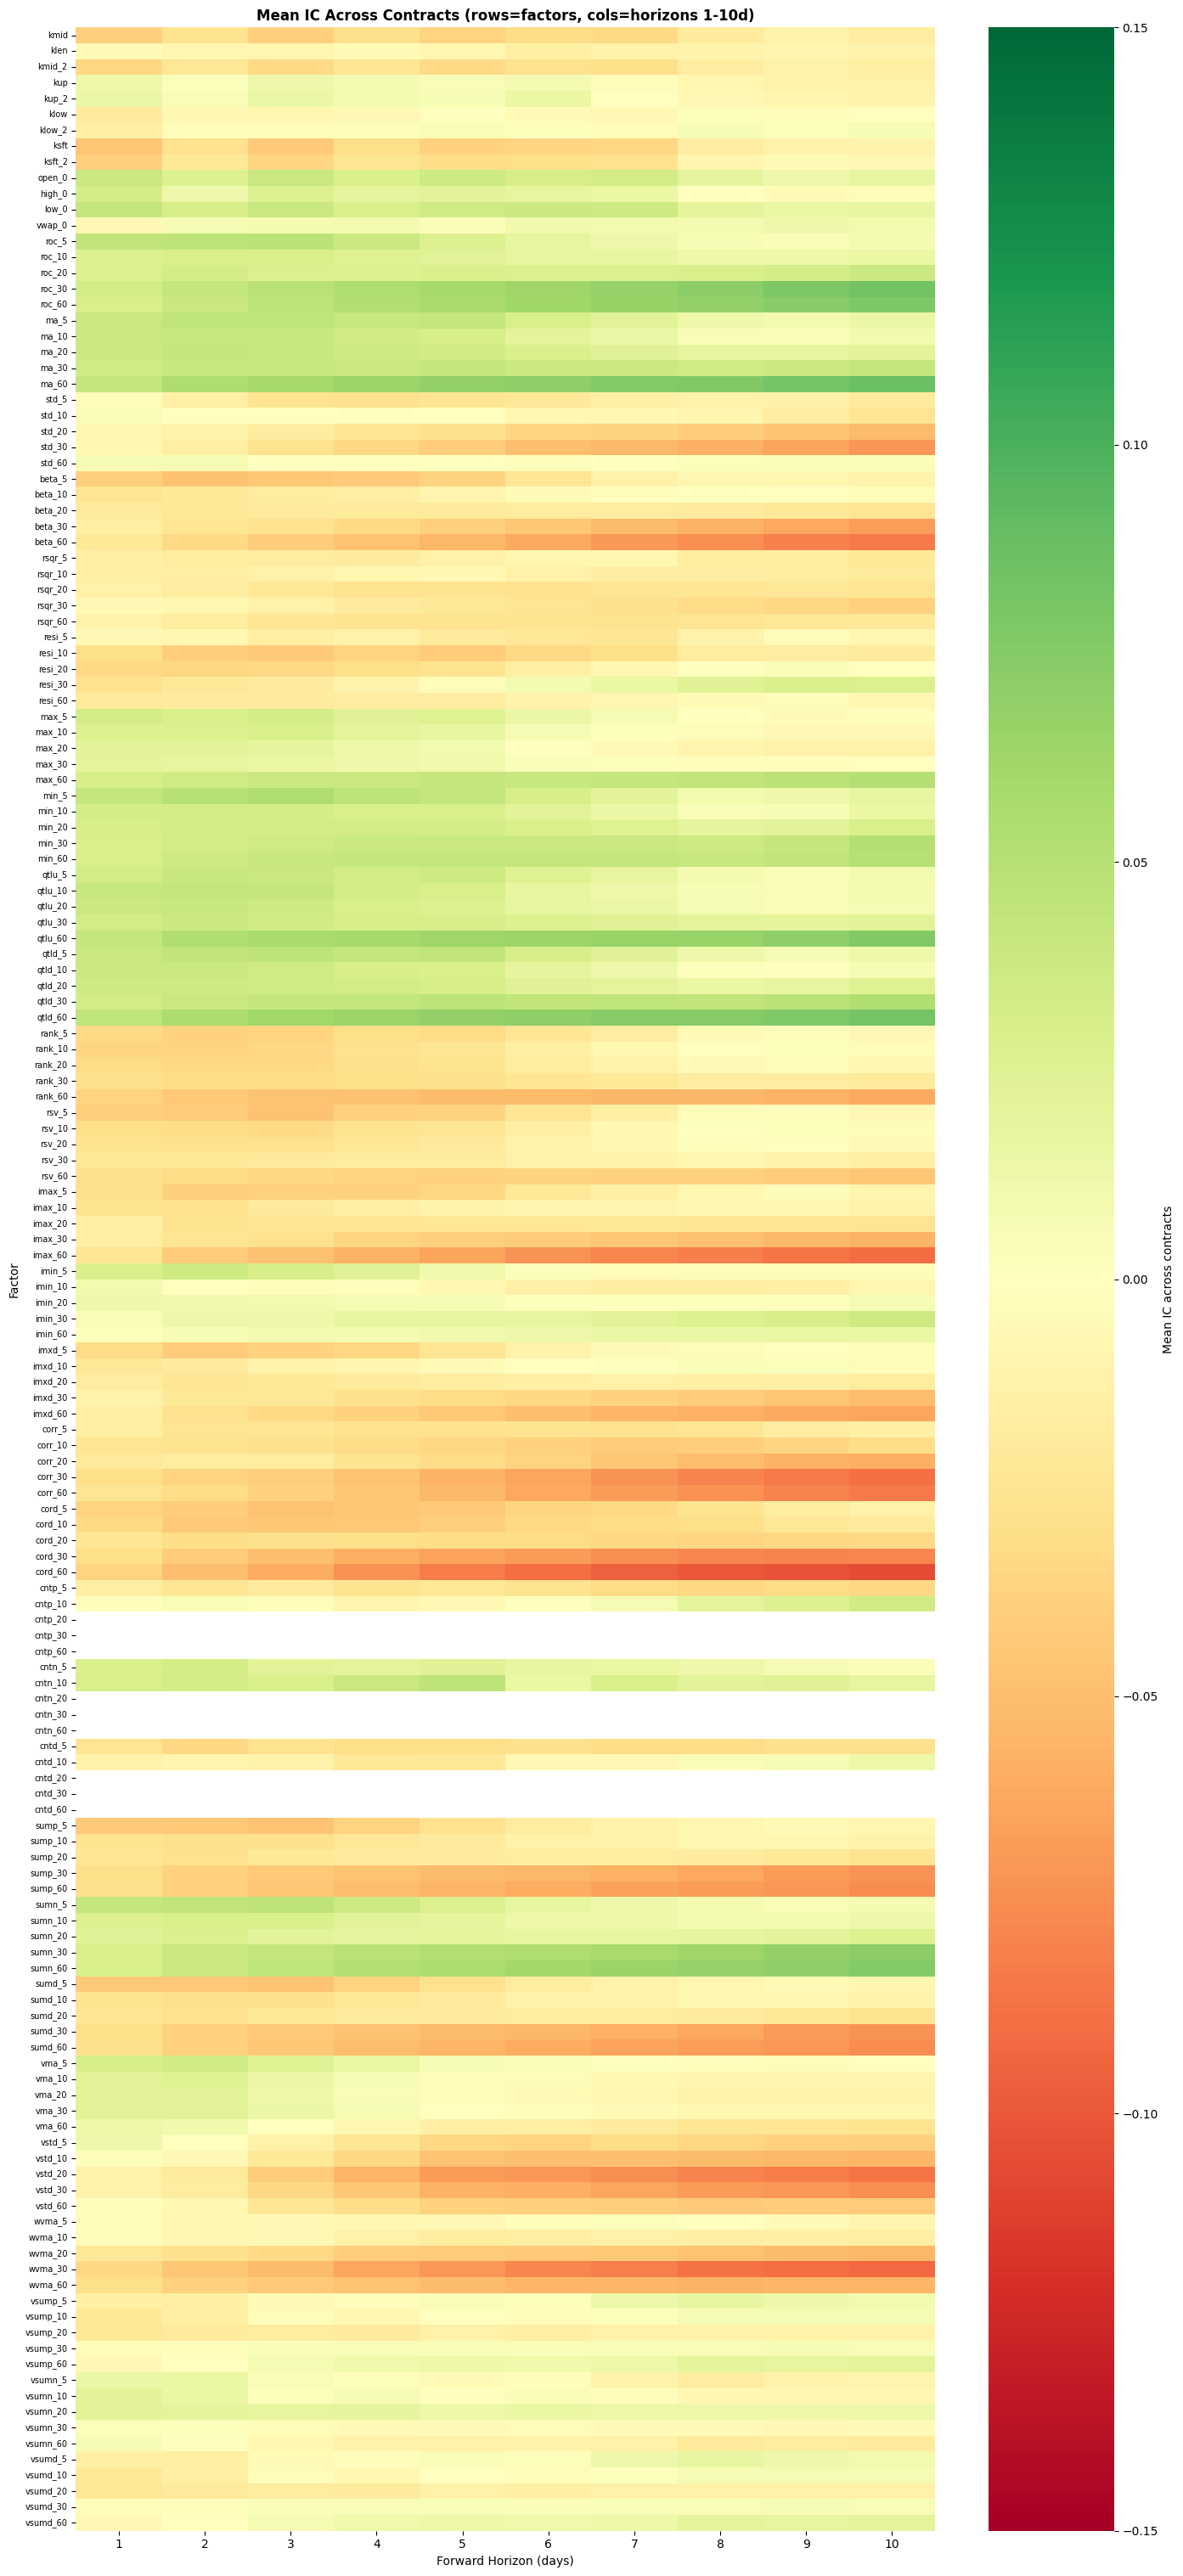

Saved: ts_ic_summary.png


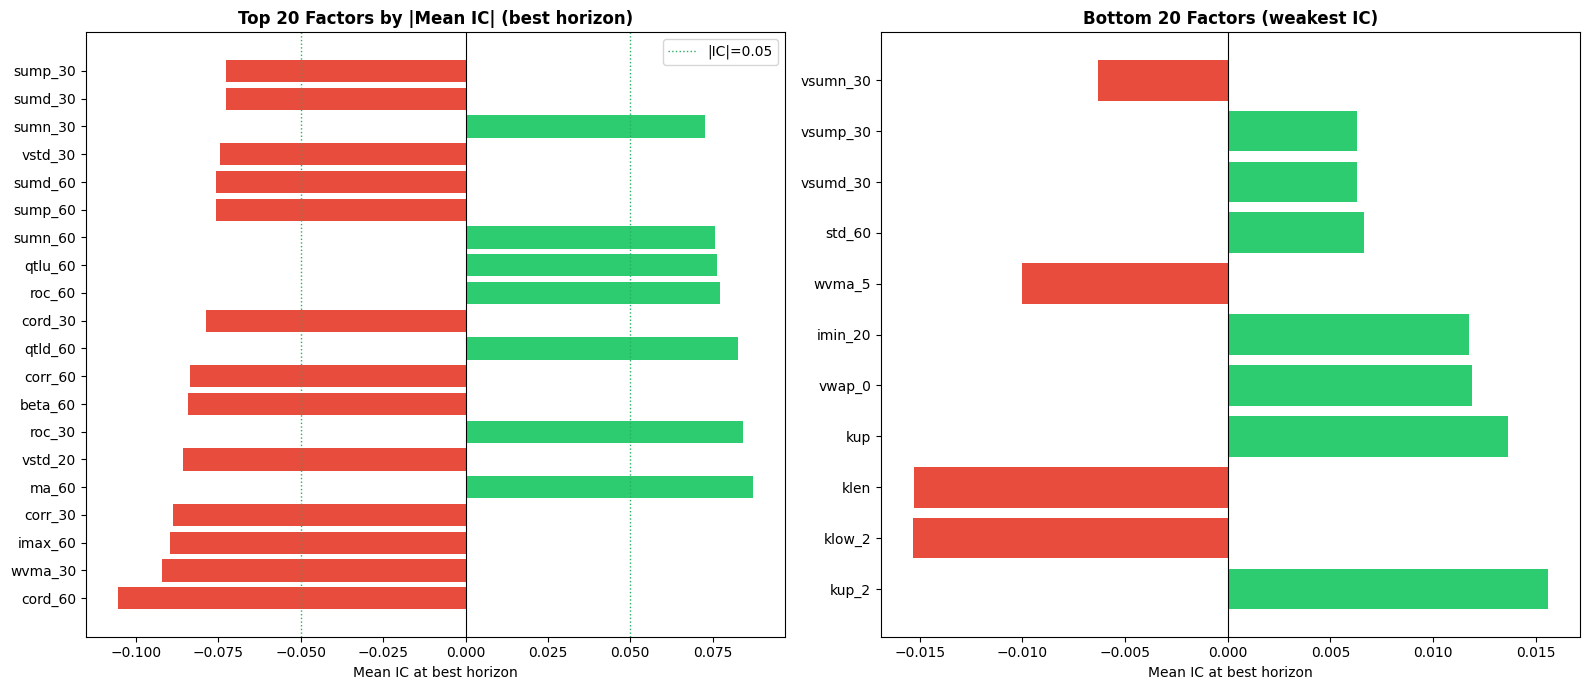

Saved: ts_ic_top_bottom.png

Top 20 factors by |ICIR| (best horizon):


,factor,best_horizon,ICIR
0,cntn_10,4,16.513023
1,cord_60,3,-1.838771
2,wvma_30,8,-1.704341
3,qtld_5,1,1.635856
4,min_5,1,1.607918
5,ma_5,1,1.570540
6,rank_5,2,-1.422730
7,ksft,1,-1.416080
8,qtlu_10,1,1.386833
9,beta_5,1,-1.372635



ICIR across horizons (top 20 factors):


horizon,1,2,3,4,5,6,7,8,9,10
factor,,,,,,,,,,
cntn_10,1.17,1.21,1.52,16.51,10.02,0.41,1.66,0.68,0.63,0.46
cord_60,-1.42,-1.73,-1.84,-1.77,-1.61,-1.55,-1.52,-1.51,-1.49,-1.44
wvma_30,-1.46,-1.23,-1.25,-1.47,-1.55,-1.66,-1.64,-1.70,-1.60,-1.56
qtld_5,1.64,1.55,1.06,0.80,0.79,0.56,0.41,0.19,0.11,0.18
min_5,1.61,1.26,1.05,0.79,0.70,0.46,0.29,0.12,0.13,0.19
ma_5,1.57,1.46,0.94,0.76,0.74,0.54,0.40,0.21,0.14,0.22
rank_5,-1.35,-1.42,-1.05,-0.74,-0.74,-0.58,-0.41,-0.13,-0.04,-0.12
ksft,-1.42,-1.04,-1.24,-0.82,-1.02,-0.96,-1.07,-0.46,-0.26,-0.26
qtlu_10,1.39,1.34,0.94,0.63,0.47,0.28,0.19,0.09,0.07,0.11


In [5]:
factor_names = list(FACTORS.keys())
n_factors = len(factor_names)

# ── Chart A: Cross-factor summary — rows=factors, cols=horizons ──────
# With 158 factors, show mean IC across contracts per (factor, horizon)
summary_pivot = (
    ic_df.groupby(["factor", "horizon"])["IC"]
    .mean()
    .reset_index()
    .pivot(index="factor", columns="horizon", values="IC")
    .reindex(columns=HORIZONS)
    .reindex(factor_names)
)

fig, ax = plt.subplots(figsize=(14, max(8, n_factors * 0.18 + 2)))
sns.heatmap(
    summary_pivot, ax=ax, center=0, cmap="RdYlGn",
    linewidths=0,
    vmin=-0.15, vmax=0.15,
    xticklabels=HORIZONS,
    yticklabels=True,
    cbar_kws={"label": "Mean IC across contracts"}
)
ax.set_title("Mean IC Across Contracts (rows=factors, cols=horizons 1-10d)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Forward Horizon (days)")
ax.set_ylabel("Factor")
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig("./lab/futures/ts_ic_summary.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: ts_ic_summary.png")

# ── Chart B: Top/bottom 20 factors by |mean IC| at best horizon ──────
best_ic_per_factor = (
    ic_df.groupby(["factor", "horizon"])["IC"]
    .mean()
    .reset_index()
    .assign(abs_IC=lambda x: x["IC"].abs())
    .sort_values("abs_IC", ascending=False)
    .groupby("factor")
    .first()
    .reset_index()
    .sort_values("abs_IC", ascending=False)
)

top20 = best_ic_per_factor.head(20)
bot20 = best_ic_per_factor.tail(20)

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
colors_top = ["#2ecc71" if v > 0 else "#e74c3c" for v in top20["IC"]]
ax1.barh(top20["factor"], top20["IC"], color=colors_top)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.axvline(0.05, color="#27ae60", linewidth=1, linestyle=":", label="|IC|=0.05")
ax1.axvline(-0.05, color="#27ae60", linewidth=1, linestyle=":")
ax1.set_title("Top 20 Factors by |Mean IC| (best horizon)", fontweight="bold")
ax1.set_xlabel("Mean IC at best horizon")
ax1.legend()

colors_bot = ["#2ecc71" if v > 0 else "#e74c3c" for v in bot20["IC"]]
ax2.barh(bot20["factor"], bot20["IC"], color=colors_bot)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_title("Bottom 20 Factors (weakest IC)", fontweight="bold")
ax2.set_xlabel("Mean IC at best horizon")

plt.tight_layout()
plt.savefig("./lab/futures/ts_ic_top_bottom.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: ts_ic_top_bottom.png")

# ── ICIR table — top 20 ───────────────────────────────────────────────
icir_per_factor = (
    ic_df.groupby(["factor", "horizon"])["IC"]
    .agg(lambda x: x.mean() / x.std() if x.std() > 0 else 0)
    .reset_index()
    .assign(abs_ICIR=lambda x: x["IC"].abs())
    .sort_values("abs_ICIR", ascending=False)
    .groupby("factor")
    .first()
    .reset_index()
    .rename(columns={"IC": "ICIR", "horizon": "best_horizon"})
    .sort_values("abs_ICIR", ascending=False)
)

print(f"\nTop 20 factors by |ICIR| (best horizon):")
display(icir_per_factor[["factor", "best_horizon", "ICIR"]].head(20).reset_index(drop=True))

# ── IC summary pivot (mean IC, top 20 factors × all horizons) ─────────
top20_factors = icir_per_factor.head(20)["factor"].tolist()
icir_pivot = (
    ic_df[ic_df["factor"].isin(top20_factors)]
    .groupby(["factor", "horizon"])["IC"]
    .agg(lambda x: x.mean() / x.std() if x.std() > 0 else 0)
    .reset_index()
    .pivot(index="factor", columns="horizon", values="IC")
    .reindex(columns=HORIZONS)
    .reindex(top20_factors)
    .round(2)
)
print(f"\nICIR across horizons (top 20 factors):")
display(icir_pivot)

## Cell 6 — ML Per Contract (LightGBM)

For each selected contract, train a separate LightGBM model:
- Features: all factors in `FACTORS`  
- Label: `ML_HORIZON`-day forward return  
- Evaluate on OOS test period: IC, directional accuracy, Sharpe

Uses `num_leaves=16` (small tree) to reduce overfitting risk on ~500 training rows.

In [6]:
from functools import partial
from tqdm import tqdm as tqdm_nb
from vnpy.alpha.dataset.processor import process_drop_na, process_robust_zscore_norm

ml_results = []

for symbol in tqdm_nb(SELECTED, desc="ML Training"):
    df_c = df.filter(pl.col("vt_symbol") == symbol)

    dataset = AlphaDataset(df_c, TRAIN_PERIOD, VALID_PERIOD, TEST_PERIOD)

    for name, expr in FACTORS.items():
        dataset.add_feature(name, expr)

    dataset.set_label(f"ts_delay(close, -{ML_HORIZON}) / close - 1")
    dataset.prepare_data(max_workers=1)

    # Drop rows with NaN labels, then normalise features
    dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
    dataset.add_processor("infer", partial(process_drop_na, names=["label"]))
    dataset.add_processor("infer", process_robust_zscore_norm)
    dataset.add_processor("learn", process_robust_zscore_norm)
    dataset.process_data()

    train_rows = len(dataset.fetch_learn(Segment.TRAIN))
    if train_rows < 100:
        print(f"  WARN: {symbol} only {train_rows} training rows -- skipping ML")
        continue

    model = LgbModel(
        learning_rate=0.05,
        num_leaves=16,
        num_boost_round=500,
        early_stopping_rounds=30,
        log_evaluation_period=100,
        seed=42
    )
    model.fit(dataset)

    # Predict on test
    preds = model.predict(dataset, Segment.TEST)
    test_df = dataset.fetch_infer(Segment.TEST).sort(["datetime", "vt_symbol"]).to_pandas().dropna()

    if len(test_df) == 0:
        print(f"  WARN: {symbol} no test rows after dropna")
        continue

    test_df["pred"] = preds[:len(test_df)]
    test_df = test_df.dropna(subset=["label", "pred"])

    if len(test_df) < 20:
        print(f"  WARN: {symbol} insufficient test rows ({len(test_df)})")
        continue

    # OOS IC
    oos_ic, _ = spearmanr(test_df["pred"], test_df["label"])

    # Directional accuracy
    dir_acc = (np.sign(test_df["pred"]) == np.sign(test_df["label"])).mean()

    # Simple long/short daily Sharpe: go long when pred>0, short when pred<0
    df_raw_c = df.filter(pl.col("vt_symbol") == symbol).sort("datetime").to_pandas()
    df_raw_c["ret_1d"] = df_raw_c["close"].pct_change(1).shift(-1)
    df_raw_c["datetime"] = pd.to_datetime(df_raw_c["datetime"])
    test_df["datetime"] = pd.to_datetime(test_df["datetime"])

    merged = test_df.merge(df_raw_c[["datetime", "ret_1d"]], on="datetime", how="left").dropna(subset=["ret_1d"])

    signal_ret = np.sign(merged["pred"]) * merged["ret_1d"]
    sharpe = (signal_ret.mean() / signal_ret.std()) * np.sqrt(242) if signal_ret.std() > 0 else 0.0
    total_ret = (1 + signal_ret).prod() - 1

    ml_results.append({
        "symbol": symbol,
        "train_rows": train_rows,
        "test_rows": len(test_df),
        "OOS_IC": round(oos_ic, 4),
        "Dir_Acc": round(dir_acc, 4),
        "OOS_Sharpe": round(sharpe, 3),
        "OOS_TotalRet": round(total_ret * 100, 2),
    })

ml_df = pd.DataFrame(ml_results).sort_values("OOS_Sharpe", ascending=False)
print(f"\nML results for {len(ml_df)} contracts (sorted by OOS Sharpe):")
display(ml_df)

ML Training:   0%|          | 0/15 [00:00<?, ?it/s]

2026-03-29 23:01:01 开始计算表达式因子特征


  0%|          | 0/159 [00:00<?, ?it/s]

Feature calculation kmid took: 0.0010018348693847656 seconds | (close - open) / open
Feature calculation klen took: 0.0 seconds | (high - low) / open
Feature calculation kmid_2 took: 0.0009903907775878906 seconds | (close - open) / (high - low + 1e-12)
Feature calculation kup took: 0.006524562835693359 seconds | (high - ts_greater(open, close)) / open
Feature calculation kup_2 took: 0.0070002079010009766 seconds | (high - ts_greater(open, close)) / (high - low + 1e-12)
Feature calculation klow took: 0.0049991607666015625 seconds | (ts_less(open, close) - low) / open
Feature calculation klow_2 took: 0.0050008296966552734 seconds | ((ts_less(open, close) - low) / (high - low + 1e-12))
Feature calculation ksft took: 0.001009225845336914 seconds | (close * 2 - high - low) / open
Feature calculation ksft_2 took: 0.0009908676147460938 seconds | (close * 2 - high - low) / (high - low + 1e-12)
Feature calculation open_0 took: 0.0 seconds | open / close
Feature calculation high_0 took: 0.000999

 13%|█▎        | 21/159 [00:00<00:00, 179.22it/s]

...

0it [00:00, ?it/s]

ML Training: 100%|██████████| 15/15 [00:49<00:00,  3.19s/it]

ML Training: 100%|██████████| 15/15 [00:49<00:00,  3.30s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001990 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30262
[LightGBM] [Info] Number of data points in the train set: 729, number of used features: 145
[LightGBM] [Info] Start training from score 0.002774
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[6]	train's l2: 0.000972615	valid's l2: 0.00133494

ML results for 15 contracts (sorted by OOS Sharpe):


,symbol,train_rows,test_rows,OOS_IC,Dir_Acc,OOS_Sharpe,OOS_TotalRet
6,ag88.SHFE,729,479,-0.0133,0.5407,0.848,40.54
7,ru88.SHFE,729,479,0.0745,0.5344,0.828,35.46
13,pp88.DCE,729,479,0.0528,0.5010,0.614,12.56
2,cu88.SHFE,729,479,-0.0365,0.5031,0.593,15.41
11,al88.SHFE,729,479,-0.0278,0.5157,0.398,8.89
1,TA88.CZCE,728,479,-0.0218,0.5073,0.361,10.54
10,zn88.SHFE,729,479,0.0440,0.5303,0.278,6.83
4,p88.DCE,729,479,-0.0368,0.5219,0.225,5.14
14,hc88.SHFE,729,479,0.0414,0.4885,0.097,0.33
12,SR88.CZCE,728,479,-0.0888,0.5010,0.020,-1.32


## Cell 7 — Summary Report

 SUMMARY: Time-Series Factor Research
 Factors tested: ['kmid', 'klen', 'kmid_2', 'kup', 'kup_2', 'klow', 'klow_2', 'ksft', 'ksft_2', 'open_0', 'high_0', 'low_0', 'vwap_0', 'roc_5', 'roc_10', 'roc_20', 'roc_30', 'roc_60', 'ma_5', 'ma_10', 'ma_20', 'ma_30', 'ma_60', 'std_5', 'std_10', 'std_20', 'std_30', 'std_60', 'beta_5', 'beta_10', 'beta_20', 'beta_30', 'beta_60', 'rsqr_5', 'rsqr_10', 'rsqr_20', 'rsqr_30', 'rsqr_60', 'resi_5', 'resi_10', 'resi_20', 'resi_30', 'resi_60', 'max_5', 'max_10', 'max_20', 'max_30', 'max_60', 'min_5', 'min_10', 'min_20', 'min_30', 'min_60', 'qtlu_5', 'qtlu_10', 'qtlu_20', 'qtlu_30', 'qtlu_60', 'qtld_5', 'qtld_10', 'qtld_20', 'qtld_30', 'qtld_60', 'rank_5', 'rank_10', 'rank_20', 'rank_30', 'rank_60', 'rsv_5', 'rsv_10', 'rsv_20', 'rsv_30', 'rsv_60', 'imax_5', 'imax_10', 'imax_20', 'imax_30', 'imax_60', 'imin_5', 'imin_10', 'imin_20', 'imin_30', 'imin_60', 'imxd_5', 'imxd_10', 'imxd_20', 'imxd_30', 'imxd_60', 'corr_5', 'corr_10', 'corr_20', 'corr_30', 'corr_60'

,Contract,Best Factor,Best Factor |IC|,Best Horizon,OOS IC,OOS Sharpe,OOS Total Ret (%),Directional Acc
1,ag88.SHFE,imax_5,0.1178,8,-0.0133,0.848,40.54,0.5407
2,ru88.SHFE,std_20,0.2047,10,0.0745,0.828,35.46,0.5344
3,pp88.DCE,corr_20,0.2220,8,0.0528,0.614,12.56,0.5010
4,cu88.SHFE,corr_60,0.1777,10,-0.0365,0.593,15.41,0.5031
5,al88.SHFE,beta_20,0.2068,7,-0.0278,0.398,8.89,0.5157
6,TA88.CZCE,cord_60,0.1786,10,-0.0218,0.361,10.54,0.5073
7,zn88.SHFE,resi_20,0.1245,8,0.0440,0.278,6.83,0.5303
8,p88.DCE,vstd_30,0.2126,9,-0.0368,0.225,5.14,0.5219
9,hc88.SHFE,klen,0.1068,9,0.0414,0.097,0.33,0.4885
10,SR88.CZCE,ma_60,0.2200,10,-0.0888,0.020,-1.32,0.5010


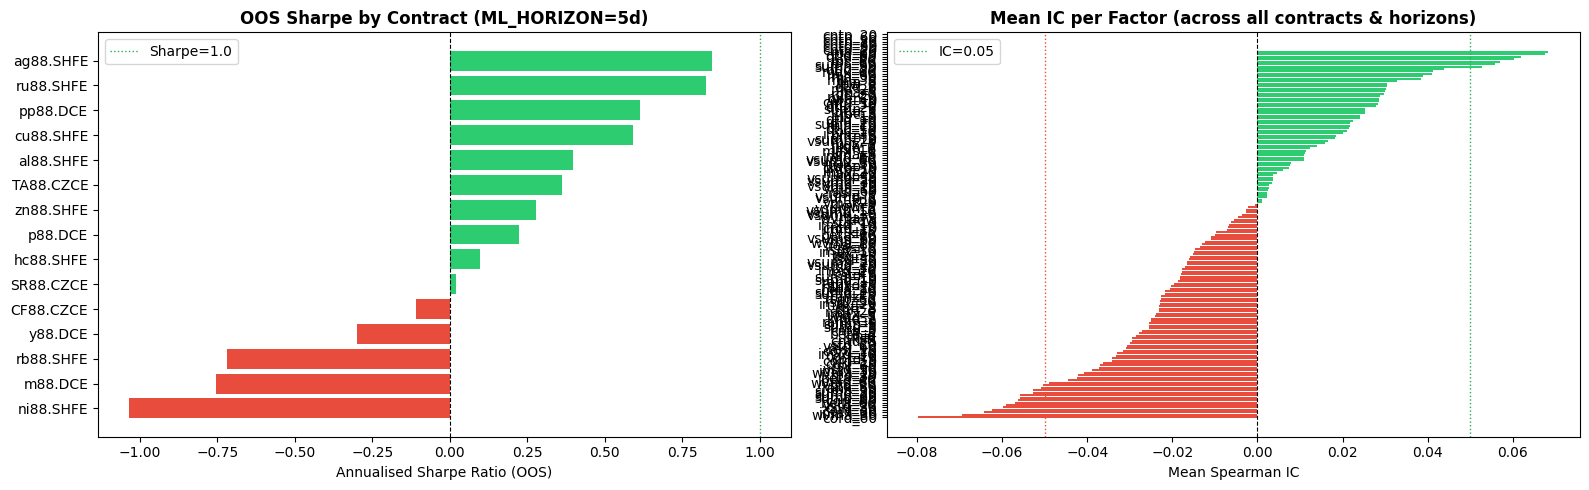

Saved: ts_summary.png

── Contracts with OOS Sharpe > 0.5 ──


,symbol,train_rows,test_rows,OOS_IC,Dir_Acc,OOS_Sharpe,OOS_TotalRet
6,ag88.SHFE,729,479,-0.0133,0.5407,0.848,40.54
7,ru88.SHFE,729,479,0.0745,0.5344,0.828,35.46
13,pp88.DCE,729,479,0.0528,0.5010,0.614,12.56
2,cu88.SHFE,729,479,-0.0365,0.5031,0.593,15.41



── Factors with |mean IC| > 0.05 ──


,factor,IC
24,cord_60,-0.079665
155,wvma_30,-0.069469
35,imax_60,-0.064297
22,cord_30,-0.062351
27,corr_30,-0.059769
133,vstd_20,-0.059123
4,beta_60,-0.057054
29,corr_60,-0.056302
116,sumd_60,-0.055718
126,sump_60,-0.055715


In [7]:
# ── Best factor per contract (by |mean IC| over HORIZONS) ───────────
best_factor = (
    ic_df.groupby(["symbol", "factor"])["IC"]
    .agg(lambda x: abs(x.mean()))
    .reset_index()
    .rename(columns={"IC": "abs_mean_IC"})
    .sort_values("abs_mean_IC", ascending=False)
    .groupby("symbol")
    .first()
    .reset_index()[["symbol", "factor", "abs_mean_IC"]]
    .rename(columns={"factor": "best_factor", "abs_mean_IC": "best_factor_IC"})
)

# Best horizon per contract
best_horizon = (
    ic_df.groupby(["symbol", "horizon"])["IC"]
    .agg(lambda x: abs(x.mean()))
    .reset_index()
    .rename(columns={"IC": "abs_mean_IC"})
    .sort_values("abs_mean_IC", ascending=False)
    .groupby("symbol")
    .first()
    .reset_index()[["symbol", "horizon"]]
    .rename(columns={"horizon": "best_horizon"})
)

# Merge with ML results
summary = best_factor.merge(best_horizon, on="symbol", how="left")
if len(ml_df) > 0:
    summary = summary.merge(ml_df[["symbol", "OOS_IC", "OOS_Sharpe", "OOS_TotalRet", "Dir_Acc"]],
                            on="symbol", how="left")

summary = summary.sort_values("OOS_Sharpe", ascending=False).reset_index(drop=True)
summary.index += 1
summary.columns = ["Contract", "Best Factor", "Best Factor |IC|", "Best Horizon",
                   "OOS IC", "OOS Sharpe", "OOS Total Ret (%)", "Directional Acc"]

print("="*80)
print(" SUMMARY: Time-Series Factor Research")
print(f" Factors tested: {list(FACTORS.keys())}")
print(f" Horizons: 1-{max(HORIZONS)}d | ML horizon: {ML_HORIZON}d")
print("="*80)
display(summary.round(4))

# ── Chart: OOS Sharpe per contract ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

if len(ml_df) > 0:
    ml_plot = ml_df.sort_values("OOS_Sharpe")
    colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in ml_plot["OOS_Sharpe"]]
    ax1.barh(ml_plot["symbol"], ml_plot["OOS_Sharpe"], color=colors)
    ax1.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax1.axvline(1.0, color="#27ae60", linewidth=1, linestyle=":", label="Sharpe=1.0")
    ax1.set_title(f"OOS Sharpe by Contract (ML_HORIZON={ML_HORIZON}d)", fontweight="bold")
    ax1.set_xlabel("Annualised Sharpe Ratio (OOS)")
    ax1.legend()

# Mean |IC| per factor (bar chart)
mean_ic_factor = (
    ic_df.groupby("factor")["IC"]
    .agg(lambda x: x.mean())
    .reset_index()
    .sort_values("IC", ascending=True)
)
colors2 = ["#2ecc71" if v > 0 else "#e74c3c" for v in mean_ic_factor["IC"]]
ax2.barh(mean_ic_factor["factor"], mean_ic_factor["IC"], color=colors2)
ax2.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax2.axvline(0.05, color="#27ae60", linewidth=1, linestyle=":", label="IC=0.05")
ax2.axvline(-0.05, color="#e74c3c", linewidth=1, linestyle=":")
ax2.set_title("Mean IC per Factor (across all contracts & horizons)", fontweight="bold")
ax2.set_xlabel("Mean Spearman IC")
ax2.legend()

plt.tight_layout()
plt.savefig("./lab/futures/ts_summary.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: ts_summary.png")

# Highlight strong signals
print("\n── Contracts with OOS Sharpe > 0.5 ──")
if len(ml_df) > 0:
    strong = ml_df[ml_df["OOS_Sharpe"] > 0.5]
    if len(strong) > 0:
        display(strong)
    else:
        print("  None found — consider adding more factors or adjusting ML_HORIZON")

print("\n── Factors with |mean IC| > 0.05 ──")
strong_ic = mean_ic_factor[abs(mean_ic_factor["IC"]) > 0.05]
if len(strong_ic) > 0:
    display(strong_ic)
else:
    print("  None found — factors may be weak for this universe/period")